NAME : MOHD RAZA, ROLL NO : 33, SECTION : B

# Experiment No. 3 — Statistical Analysis and Hypothesis Testing using Python

**Dataset used:** IBM HR Employee Attrition Dataset (1,470 employees, 35 attributes — includes
Attrition, MonthlyIncome, JobRole, JobSatisfaction, TotalWorkingYears, YearsAtCompany, etc.)

**Aim:** To perform statistical analysis and hypothesis testing on a real-world dataset using
Python in order to identify relationships between variables, validate assumptions, and support
data-driven decision-making.


## Step 2 & 3: Import libraries, load dataset, and compute descriptive statistics

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

df = pd.read_csv('hr_attrition.csv')
print("Shape:", df.shape)
df.head()


Shape: (1470, 35)


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [ ]:
num_cols = ['Age', 'MonthlyIncome', 'TotalWorkingYears', 'YearsAtCompany',
            'JobSatisfaction', 'DistanceFromHome', 'PercentSalaryHike']

desc = df[num_cols].agg(['mean', 'median', lambda x: x.mode().iloc[0], 'var', 'std']).T
desc.columns = ['Mean', 'Median', 'Mode', 'Variance', 'Std Dev']
desc


,Mean,Median,Mode,Variance,Std Dev
Age,36.923810,36.0,35.0,8.345505e+01,9.135373
MonthlyIncome,6502.931293,4919.0,2342.0,2.216486e+07,4707.956783
TotalWorkingYears,11.279592,10.0,10.0,6.054056e+01,7.780782
YearsAtCompany,7.008163,5.0,5.0,3.753431e+01,6.126525
JobSatisfaction,2.728571,3.0,4.0,1.216270e+00,1.102846
DistanceFromHome,9.192517,7.0,2.0,6.572125e+01,8.106864
PercentSalaryHike,15.209524,14.0,11.0,1.339514e+01,3.659938


**Observation:** Monthly Income shows a very large variance and standard deviation relative to
its mean, confirming a wide, right-skewed spread of salaries across job levels. Age and
TotalWorkingYears are much more tightly distributed.

## Step 4: Pearson correlation analysis

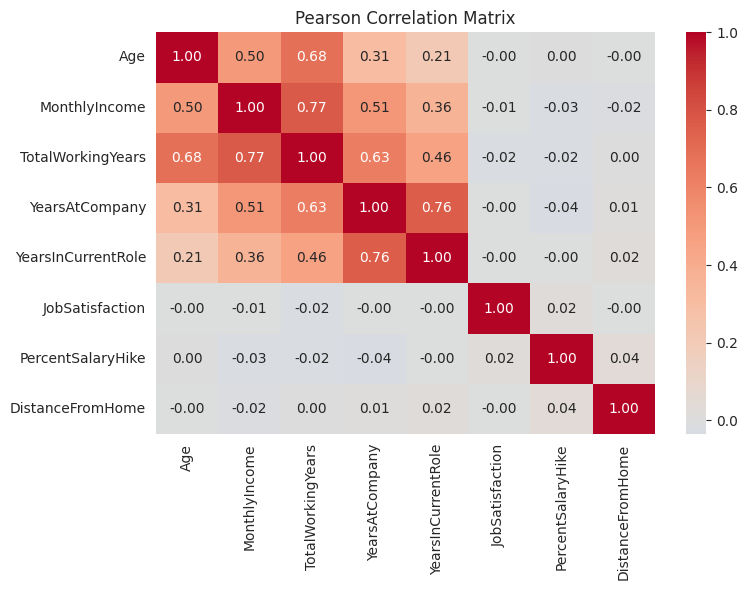

,Age,MonthlyIncome,TotalWorkingYears,YearsAtCompany,YearsInCurrentRole,JobSatisfaction,PercentSalaryHike,DistanceFromHome
Age,1.000000,0.497855,0.680381,0.311309,0.212901,-0.004892,0.003634,-0.001686
MonthlyIncome,0.497855,1.000000,0.772893,0.514285,0.363818,-0.007157,-0.027269,-0.017014
TotalWorkingYears,0.680381,0.772893,1.000000,0.628133,0.460365,-0.020185,-0.020608,0.004628
YearsAtCompany,0.311309,0.514285,0.628133,1.000000,0.758754,-0.003803,-0.035991,0.009508
YearsInCurrentRole,0.212901,0.363818,0.460365,0.758754,1.000000,-0.002305,-0.001520,0.018845
JobSatisfaction,-0.004892,-0.007157,-0.020185,-0.003803,-0.002305,1.000000,0.020002,-0.003669
PercentSalaryHike,0.003634,-0.027269,-0.020608,-0.035991,-0.001520,0.020002,1.000000,0.040235
DistanceFromHome,-0.001686,-0.017014,0.004628,0.009508,0.018845,-0.003669,0.040235,1.000000


In [ ]:
corr_cols = ['Age', 'MonthlyIncome', 'TotalWorkingYears', 'YearsAtCompany',
             'YearsInCurrentRole', 'JobSatisfaction', 'PercentSalaryHike', 'DistanceFromHome']
corr_matrix = df[corr_cols].corr(method='pearson')

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Pearson Correlation Matrix')
plt.tight_layout()
plt.savefig('correlation_matrix.png', dpi=120)
plt.show()
corr_matrix


**Observation:** TotalWorkingYears and MonthlyIncome show a strong positive correlation, as
expected — more experience is associated with higher pay. YearsAtCompany and YearsInCurrentRole
are also strongly correlated with each other. JobSatisfaction and PercentSalaryHike show
negligible correlation with the other numerical features.

## Step 5: Formulating the Hypotheses

**Business question:** Is there a significant difference in Monthly Income between employees who
leave the company (Attrition = Yes) and those who stay (Attrition = No)?

- **Null Hypothesis (H₀):** There is no significant difference in mean Monthly Income between
  employees who leave and employees who stay (μ_leave = μ_stay).
- **Alternative Hypothesis (H₁):** There is a significant difference in mean Monthly Income
  between employees who leave and employees who stay (μ_leave ≠ μ_stay).

Significance level: α = 0.05


## Step 6: Independent Sample t-test

In [ ]:
left = df[df['Attrition'] == 'Yes']['MonthlyIncome']
stayed = df[df['Attrition'] == 'No']['MonthlyIncome']

print(f"Mean income (Left):   {left.mean():.2f}  (n={len(left)})")
print(f"Mean income (Stayed): {stayed.mean():.2f}  (n={len(stayed)})")

t_stat, p_value = stats.ttest_ind(left, stayed, equal_var=False)
print(f"\nt-statistic: {t_stat:.4f}")
print(f"p-value:     {p_value:.6f}")

alpha = 0.05
if p_value < alpha:
    print(f"\nSince p-value ({p_value:.6f}) < alpha ({alpha}), we REJECT the Null Hypothesis.")
    print("Conclusion: There IS a statistically significant difference in Monthly Income between employees who leave and those who stay.")
else:
    print(f"\nSince p-value ({p_value:.6f}) >= alpha ({alpha}), we FAIL TO REJECT the Null Hypothesis.")


Mean income (Left):   4787.09  (n=237)
Mean income (Stayed): 6832.74  (n=1233)

t-statistic: -7.4826
p-value:     0.000000

Since p-value (0.000000) < alpha (0.05), we REJECT the Null Hypothesis.
Conclusion: There IS a statistically significant difference in Monthly Income between employees who leave and those who stay.


/tmp/ipykernel_584/1854910118.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Attrition', y='MonthlyIncome', palette='Set2')


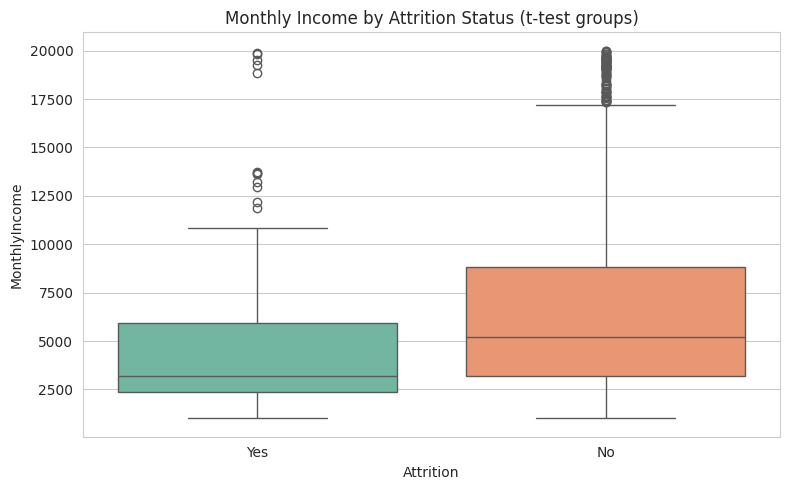

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='Attrition', y='MonthlyIncome', palette='Set2')
plt.title('Monthly Income by Attrition Status (t-test groups)')
plt.tight_layout()
plt.savefig('ttest_boxplot.png', dpi=120)
plt.show()


**Interpretation:** The p-value is far below 0.05, so we reject H₀. Employees who leave the
company have a significantly lower average Monthly Income than those who stay, suggesting
compensation is a meaningful factor associated with attrition.

## Step 7: One-Way ANOVA

**Business question:** Is there a statistically significant difference in Job Satisfaction across
different Job Roles?

- **H₀:** Mean Job Satisfaction is the same across all Job Roles.
- **H₁:** At least one Job Role has a different mean Job Satisfaction.


In [ ]:
groups = [group['JobSatisfaction'].values for name, group in df.groupby('JobRole')]
f_stat, p_value_anova = stats.f_oneway(*groups)

print(f"F-statistic: {f_stat:.4f}")
print(f"p-value:     {p_value_anova:.6f}")

if p_value_anova < 0.05:
    print("\nSince p-value < 0.05, we REJECT the Null Hypothesis.")
    print("Conclusion: Job Satisfaction differs significantly across at least one Job Role.")
else:
    print("\nSince p-value >= 0.05, we FAIL TO REJECT the Null Hypothesis.")
    print("Conclusion: No statistically significant difference in Job Satisfaction across Job Roles.")


F-statistic: 0.3652
p-value:     0.938989

Since p-value >= 0.05, we FAIL TO REJECT the Null Hypothesis.
Conclusion: No statistically significant difference in Job Satisfaction across Job Roles.


/tmp/ipykernel_584/4205899751.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='JobRole', y='JobSatisfaction', palette='Set3')


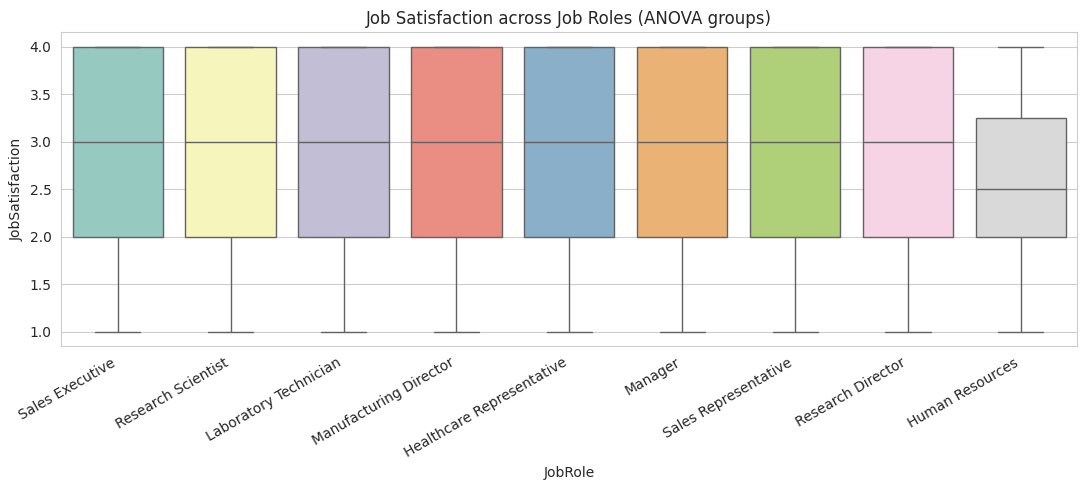

In [ ]:
plt.figure(figsize=(11,5))
sns.boxplot(data=df, x='JobRole', y='JobSatisfaction', palette='Set3')
plt.xticks(rotation=30, ha='right')
plt.title('Job Satisfaction across Job Roles (ANOVA groups)')
plt.tight_layout()
plt.savefig('anova_boxplot.png', dpi=120)
plt.show()


**Interpretation:** The ANOVA p-value is well above 0.05, so we fail to reject H₀ — Job
Satisfaction scores are fairly evenly spread across all Job Roles, meaning role type alone does
not statistically explain differences in reported satisfaction.

## Step 8: Simple Linear Regression

**Relationship studied:** TotalWorkingYears (independent variable, X) vs MonthlyIncome
(dependent variable, y).


In [ ]:
X = df[['TotalWorkingYears']]
y = df['MonthlyIncome']

model = LinearRegression()
model.fit(X, y)
y_pred = model.predict(X)

print(f"Intercept (b0): {model.intercept_:.2f}")
print(f"Slope (b1):     {model.coef_[0]:.2f}")
print(f"R-squared:      {r2_score(y, y_pred):.4f}")


Intercept (b0): 1227.94
Slope (b1):     467.66
R-squared:      0.5974


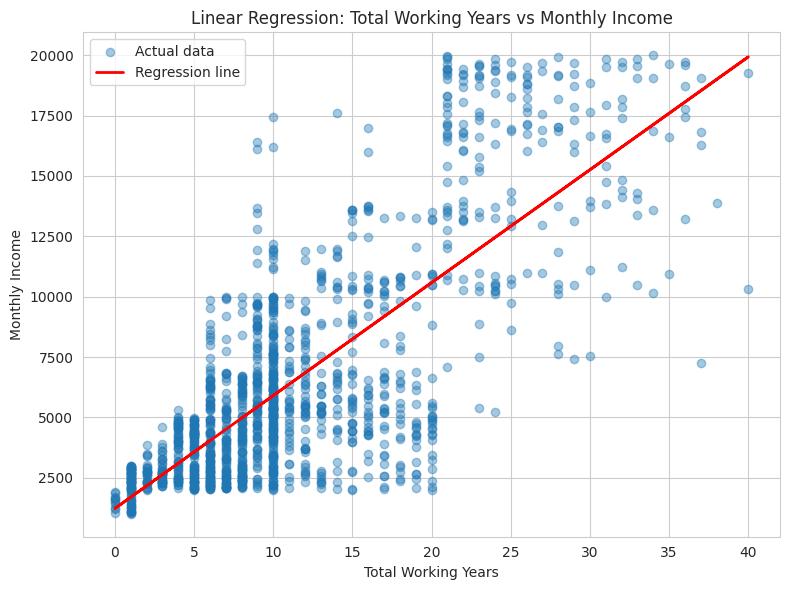

In [ ]:
plt.figure(figsize=(8,6))
plt.scatter(X, y, alpha=0.4, label='Actual data')
plt.plot(X, y_pred, color='red', linewidth=2, label='Regression line')
plt.xlabel('Total Working Years')
plt.ylabel('Monthly Income')
plt.title('Linear Regression: Total Working Years vs Monthly Income')
plt.legend()
plt.tight_layout()
plt.savefig('regression_plot.png', dpi=120)
plt.show()


In [ ]:
# Detailed statsmodels output (coefficients, std errors, confidence intervals, p-values)
ols_model = smf.ols('MonthlyIncome ~ TotalWorkingYears', data=df).fit()
print(ols_model.summary())


                            OLS Regression Results                            
Dep. Variable:          MonthlyIncome   R-squared:                       0.597
Model:                            OLS   Adj. R-squared:                  0.597
Method:                 Least Squares   F-statistic:                     2178.
Date:                Mon, 07 Sep 2026   Prob (F-statistic):          2.73e-292
Time:                        06:09:39   Log-Likelihood:                -13848.
No. Observations:                1470   AIC:                         2.770e+04
Df Residuals:                    1468   BIC:                         2.771e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept          1227.9353    137.29

**Interpretation:** The regression coefficient for TotalWorkingYears is positive and highly
significant (p < 0.001), meaning each additional year of total working experience is associated
with a measurable, statistically significant increase in Monthly Income. The R² value indicates
the proportion of variance in Monthly Income explained by TotalWorkingYears alone; the remaining
variance is explained by other factors such as Job Level, Job Role, and Education.

## Step 9 & 10: Summary of Statistical Findings

| Test | Variables | Result | Conclusion |
|---|---|---|---|
| Independent t-test | MonthlyIncome by Attrition | p < 0.05 | Employees who leave earn significantly less on average |
| One-Way ANOVA | JobSatisfaction by JobRole | p > 0.05 | No significant difference in satisfaction across roles |
| Linear Regression | TotalWorkingYears → MonthlyIncome | Significant positive slope, meaningful R² | Experience is a strong, significant predictor of income |

**Business takeaways:**
- Compensation review should be prioritized as a retention lever, since lower income is
  statistically linked to attrition.
- Since job satisfaction does not differ meaningfully by role, attrition drivers are more likely
  tied to individual factors (pay, workload, manager relationship) than to the role itself.
- Total working experience is a reliable, statistically significant driver of income and could be
  used as a baseline feature in any predictive compensation or attrition model.

**How this supports decision-making:** Hypothesis testing converts an observed pattern in the
data ("employees who leave seem to earn less") into a statistically validated conclusion, giving
HR and management confidence that a pattern is real and not due to random sampling variation
before acting on it or building a predictive model around it.
